## データの整理
### AISによる偏流データ（推定用）
lat, lonの範囲
LatIdxMax = 1500
LatIdxMin = 600
LonIdxMax = 4500
LonIdxMin = 3510<br>
AIS5は-9時間のずれ<br>
AIS4はMmsi,DtIdx,LatIdx,LonIdx,ThetaDeg,F,LineCount<br>
グリッド間隔：0.03333334,時間間隔：01:00:00<br>
DtIdx=Round((DateTime-#2011/1/1 00:00UTC#)/グリッド間隔)<br>
LatIdx=Round(Deg/グリッド間隔)<br>

### JCOPEの偏流データ（推定用）
1°あたりのメッシュ数36

eas：解析値（nowcast<br>
Lat 20-1/36～50+1/36°(30*36+2=1082個)<br> 
Lon 117-1/36～150+1/36°(33*36+2=1190個)<br>

nedo：再解析値<br>
Lat 24-1/36～48+1/36° Lon 125-1/36～148+1/36°<br>

Item: U, V （Uは東向き Vは北向き 単位m/s）表層のみ 4bytes float<br>
の値を持っている。また、陸など未定義値として1e+20を使用する。<br>

### AISの船舶データ（誤差用）
どのAISデータを使うか？<br>
AIS1: 船ごと時間ごとにソートしたもの<br>
AIS2: 重複を消したもの<br>
AIS3: 複数の船の値から偏中計算に必要な計算をしたもの<br>
AIS4: 偏流の計算結果をいれたもの<br>
各船に対する偏流の誤差を求めたいのでAIS2を使う

### AIS2のデータ
COG: 対地コース(北を基準)<br>
SOG: 対地船速<br>
HDG: 船首方位(北を基準)<br>
流されてる角度 = COG-HDG<br>
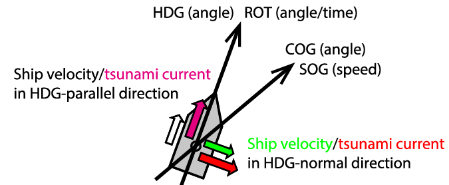

## ライブラリの取り込み

In [1]:
%matplotlib inline
import datetime
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from filterpy.gh import GHFilter
from numpy.random import randn
import seaborn as sns
import tqdm

from utils import *
from kf_params import *


### パラメータ設定

In [2]:
deg_per_mesh = 1/36
ais_lat_max = 1800
ais_lat_min = 750
ais_lon_max = 5401
ais_lon_min = 4211
lat_range = [21-1/36, 51+1/36]
lon_range = [117-1/36, 150+1/36]
map_size_ais = [1050, 1191]
map_size_jcope = [1082, 1191]

## 関数の定義

In [3]:
# dummpy jcope data
# data: 1*(n+m)
def dummy_jcope_data(x0, dx, count, noise_factor, size=[10, 10]):
    data = []
    for i in range(count):
        data.append([x0+ dx*i + randn()*noise_factor for nm in range(size[0]+size[1])])
        data[i].append(0)
    return data

# dummpy ais data
# data: 1*(n+m)
def dummy_ais_data(x0, dx, omega, count, noise_factor, size=[10, 10]):
    xy = []
    sum_w = []
    for i in range(count):
        xy.append([x0+ dx*i + randn()*noise_factor for nm in range(size[0]+size[1])])
        sum_w.append([1/(2*noise_factor)  for nm in range(size[0]+size[1])])
        xy[i].append(1)
        sum_w[i].append(0.00001)
    return xy, sum_w

# dummpy ais data
# data: 1*(n+m)
def dummy_ais_data2(x0, dx, omega, count, noise_factor, size=[10, 10]):
    v = []
    theta = []
    sum_w = []
    for i in range(count):
        v.append([x0+ dx*i + randn()*noise_factor for nm in range(size[0]+size[1])])
        theta.append([x0+ omega*i + randn()*noise_factor for nm in range(size[0]+size[1])])
        sum_w.append([1/(2*noise_factor)  for nm in range(size[0]+size[1])])
        v[i].append(1)
        theta[i].append(0)
        sum_w[i].append(0)
    return v, theta, sum_w

# lat lon -> mesh 
def latlon_to_mesh(lat, lon, size=[865, 831]):
    lat_range = [20.0-1.0/36.0, 50.0+1.0/36.0]
    lon_range = [117.0-1.0/36.0, 150.0+1.0/36.0]
    # lat, lon -> [lon, lat]
    grid0 = int((lon-lon_range[0])/deg_per_mesh)
    grid1 = int((lat-lat_range[0])/deg_per_mesh)
    if grid0<0 or grid0>size[0]: return [-1, -1]
    if grid1<0 or grid1>size[1]: return [-1, -1]
    return [grid0, grid1]

def aisIdx_to_rallon(lat_idx, lon_idx):
    return [lat_idx, lon_idx]*deg_per_mesh

# JCOPE
jcope_data = dummy_jcope_data(0, 0.1, 100, 0.01)

# AIS(観測値) 
ais_data = dummy_ais_data(0, 0.1, 1, 100, 0.001)

## データの読み込み

TODO staticが14列あり，Dynが10列なので矛盾するので読み込めないのを解決

In [4]:
import csv

# AIS2 
path_ais = [ fr'./data/ais/20150919\150919-{i}log\log' for i in range(5, 13)] # 0-14時

datas = []
for i, p in enumerate(path_ais):
    i = i+4
    with open(p+f"/japan_20150919{i*2:02}0000-20150919{i*2+1:02}5959.ais2", "r", encoding="cp932") as f:
        reader = csv.reader(f, delimiter=",", doublequote=True, lineterminator="\n", quotechar='"', skipinitialspace=False)
        for row in reader:
            if(len(row)==10):
                datas.append(row)
ais = pd.DataFrame(datas)
column_names = ["DateTimeUTC", "Dyn", "MMSI", "Navigational Status", "Lat", "Lon", "COG", "SOG", "HDG", "Hash"]
ais.columns = column_names

# 型の変換
ais["MMSI"] = ais["MMSI"].astype(np.int64)
ais["Navigational Status"] = ais["Navigational Status"].astype(np.int64)
ais["Lat"] = ais["Lat"].astype(np.float64)
ais["Lon"] = ais["Lon"].astype(np.float64)
ais["COG"] = ais["COG"].astype(np.float64)
ais["SOG"] = ais["SOG"].astype(np.float64)
ais["HDG"] = ais["HDG"].astype(np.float64)

ais.head()

,DateTimeUTC,Dyn,MMSI,Navigational Status,Lat,Lon,COG,SOG,HDG,Hash
0,2015/09/18 23:00:00,Dyn,35342354,0,34.962333,129.354217,70.6,3.2,62.0,f4338c5125a24e38
1,2015/09/18 23:00:05,Dyn,35342354,0,34.962333,129.354217,70.6,3.2,62.0,be9a45a84223e9f3
2,2015/09/18 23:00:10,Dyn,35342354,0,34.962333,129.354217,70.6,3.2,62.0,5105c77b2a374326
3,2015/09/18 23:00:15,Dyn,35342354,0,34.962333,129.354217,70.6,3.2,62.0,88506436bf232f2b
4,2015/09/18 23:00:20,Dyn,35342354,0,34.962333,129.354217,70.6,3.2,62.0,4892916ff0789bbf


In [5]:
print(f"データ量: {len(ais)}")

データ量: 9406102


In [6]:
# データの位置
#ais.plot.scatter(x='Lat', y='Lon', marker='s', c='r', s=50, alpha=0.5)

In [7]:
#pd.value_counts(ais['MMSI']).plot.bar()
#plt.show()

## データの整理

In [8]:
import copy 
ais2 = copy.deepcopy(ais)
ais2 = ais2[ais2["Lat"]>=lat_range[0]]
ais2 = ais2[ais2["Lon"]>=lon_range[0]]

# TODO intにしたときずれないか確認
lat_range2 = (np.array(lat_range)/deg_per_mesh).astype(np.int64)
lon_range2 = (np.array(lon_range)/deg_per_mesh).astype(np.int64)
ais2['LatIdx'] = (ais2['Lat']/deg_per_mesh -lat_range2[0]).astype(np.int64)
ais2['LonIdx'] = (ais2['Lon']/deg_per_mesh -lon_range2[0]).astype(np.int64)

# 時間の整理
time_utc = ais2["DateTimeUTC"].values
str_format = '%Y/%m/%d %H:%M:%S'
epoc_dt = datetime.datetime(2011, 1, 1, 0, 0, 0)
time_idx = []
tf = []
for t in time_utc:
    idx = datetime.datetime.strptime(t, str_format) 
    idx2 = idx - epoc_dt
    time_idx.append(int(idx2.days*24 + idx2.seconds / (60*60)))
time_idx = np.array(time_idx)
ais2["DtIdx"] = time_idx

min_dt = datetime.datetime(2015, 9, 19, 0, 0, 0)
min_idx = min_dt - epoc_dt
min_idx = int(min_idx.days*24 + min_idx.seconds / (60*60))
ais2 = ais2[ais2["DtIdx"] >= min_idx]
ais2.head()

,DateTimeUTC,Dyn,MMSI,Navigational Status,Lat,Lon,COG,SOG,HDG,Hash,LatIdx,LonIdx,DtIdx
571,2015/09/19 0:00:00,Dyn,35342354,0,34.962333,129.354217,70.6,3.2,62.0,a7dcaed95c4ec5f1,503,445,41328
572,2015/09/19 0:00:10,Dyn,35342354,0,34.962333,129.354217,70.6,3.2,62.0,c3f8327e62ffa019,503,445,41328
573,2015/09/19 0:00:15,Dyn,35342354,0,34.962333,129.354217,70.6,3.2,62.0,239299c9fbb366b0,503,445,41328
574,2015/09/19 0:00:20,Dyn,35342354,0,34.962333,129.354217,70.6,3.2,62.0,fb00dcd68c2e9d81,503,445,41328
575,2015/09/19 0:00:35,Dyn,35342354,0,34.962333,129.354217,70.6,3.2,62.0,cb1980d8697e295f,503,445,41328


<Axes: xlabel='LonIdx', ylabel='LatIdx'>

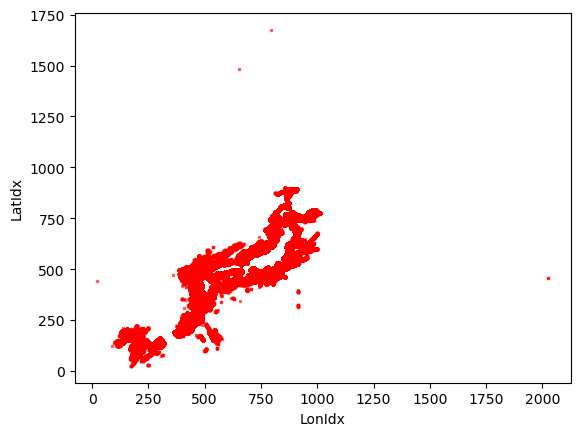

In [10]:
ais2.plot.scatter(x='LonIdx', y='LatIdx',
                marker='s', c='r', s=1, alpha=0.5)

In [ ]:
pd.value_counts(ais2[ais2["MMSI"].values[0]==ais2["MMSI"]]["DtIdx"])

## 各船に対して垂直方向の偏流

In [ ]:
ais2["CurMag"] = ais2["SOG"]*np.sin(ais2["COG"] - ais2["HDG"])
ais2["CurDir"] = ais2["HDG"] + 90
ais2[ais2["HDG"]>=360]["CurDir"] = ais2[ais2["HDG"]>=360]["CurDir"] - 360
ais2.head()

In [ ]:
real_cur_mapN = []
real_cur_mapE = []
time_set = set(ais2['DtIdx'].values)
for i in time_set:
    data = ais2[ais2["DtIdx"]==i]
    lat_lon_set = set(data["LatIdx"].astype(str) + " " 
                       + data["LonIdx"].astype(str))
    target_mapN = np.zeros(map_size_ais)
    target_mapE = np.zeros(map_size_ais)
    for lat_lon in tqdm.tqdm(lat_lon_set):
        target_tf = (lat_lon == data["LatIdx"].astype(str) + " " 
                                  + data["LonIdx"].astype(str))
        target = data[target_tf]
        lat = target["LatIdx"].values[0]
        lat = map_size_ais[0]-lat
        lon = target["LonIdx"].values[0]
        if lat<0 or lat>map_size_ais[0]: continue
        if lon<0 or lon>map_size_ais[1]: continue
        rad = azimuth_to_radian(target["CurDir"])
        target_mapN[lat][lon] = np.mean(target["CurMag"]*np.sin(rad))
        target_mapE[lat][lon] = np.mean(target["CurMag"]*np.cos(rad))
    real_cur_mapN.append(target_mapN)
    real_cur_mapE.append(target_mapE)

## データの保存

In [ ]:
# データの並び替え
import pickle
ais2 = ais2.reindex(columns=["DateTimeUTC", "DtIdx", "Dyn", "MMSI", "Navigational Status", "Lat", "Lon", "LatIdx", "LonIdx", "COG", "SOG", "HDG", "CurMag", "CurDir", "Hash"])
ais2 = ais2.sort_values("DtIdx")
save_path = 'data/ais/20150919/cur_each_ship.csv'
ais2.to_csv(save_path, index=False)

with open(f'data/ais/20150919/real_cur_mapN.pickle', 'wb') as f:
    pickle.dump(real_cur_mapN, f)
    
with open(f'data/ais/20150919/real_cur_mapE.pickle', 'wb') as f:
    pickle.dump(real_cur_mapE, f)

In [ ]:
df = pd.read_csv(save_path, encoding="cp932",)
df.head()

In [ ]:
save_path = 'data/ais/20150919/cur_each_ship.csv'
ais2 = pd.read_csv(save_path, encoding="cp932",)

In [ ]:
#tf = ais2['Lat'] > 30 * ais2['Lat'] < 36 * ais2['Lon'] > 136 * ais2['Lon'] < 142
tf1 = np.logical_and(ais2['Lat'].values > 30,  ais2['Lat'].values < 36)
tf2 = np.logical_and(ais2['Lon'].values > 136, ais2['Lon'].values < 142)
tf = np.logical_and(tf1, tf2)
np.sum(tf)